## Churn analysis On Netflix data 

In [2]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as GridSpec
import seaborn as sns 
from scipy.stats import randint
# import for ml 
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report ,precision_score,recall_score,ConfusionMatrixDisplay
# Ignore warnings 
import warnings 
warnings.filterwarnings("ignore")

# view max rows and columns 
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

## Import Data 

In [3]:
data = pd.read_csv("customer_churn_data.csv")

## Check Dimensions 

In [4]:
print(f"Customer churn data had {data.shape[0]} rows and {data.shape[1]} columns.")

Customer churn data had 2000 rows and 16 columns.


## Data Sample

In [5]:
data.head()

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2015,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2015,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2015,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2015,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


## Check Missing Values and Duplicate values

In [6]:
missing_duplicate = pd.DataFrame({"dtypes":data.dtypes,
                                  "missing values":data.isnull().sum(),
                                  "duplicate values":data.duplicated().sum()})
missing_duplicate

,dtypes,missing values,duplicate values
year,int64,0,0
customer_id,int64,0,0
phone_no,object,0,0
gender,object,24,0
age,int64,0,0
no_of_days_subscribed,int64,0,0
multi_screen,object,0,0
mail_subscribed,object,0,0
weekly_mins_watched,float64,0,0
minimum_daily_mins,float64,0,0


In [7]:
# Even though Duplicates shows null values,still we had to understand in the most impacted columns (customer_id	,phone_no)
duplicate_in_phone_no = data[data.duplicated(subset="phone_no",keep=False)]
duplicate_in_phone_no

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn


In [8]:
duplicate_in_customer_id = data[data.duplicated(subset="customer_id",keep=False)]
duplicate_in_customer_id 

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
917,2015,530490,343-7242,Female,34,59,no,yes,199.65,6.8,22.63,103,3,2.0,1,0.0
918,2015,530490,392-8905,Male,36,172,no,no,323.55,7.1,36.67,83,1,2.0,3,0.0


In [9]:
## Droping the first row
data.drop_duplicates(subset="customer_id", keep ="last",inplace=True)

### Observation
- We observed missing values in the gender, maximum_days_inactive, and churn columns.
- Initially, no duplicates were found, but deeper inspection using key identifiers like customer_id, phone_no revealed something else.
- While phone_no had no duplicates, two duplicate rows were found in the customer_id column so we dropping the first row.

In [10]:
print(f"Now updated data shape looks like {data.shape}")

Now updated data shape looks like (1999, 16)


## Missing Value Treatment 

### 1.Gender Column

In [11]:
data["gender"].value_counts(dropna=False)

gender
Male      1053
Female     922
NaN         24
Name: count, dtype: int64

- As this is Categorical column, so we are replacing NaN with Mode of Gender.

In [12]:
data["gender"].fillna(data["gender"].mode()[0],inplace=True)

In [13]:
data["gender"].value_counts(dropna=False)

gender
Male      1077
Female     922
Name: count, dtype: int64

### 2.maximum_days_inactive column

In [14]:
data["maximum_days_inactive"].value_counts(dropna=False)

maximum_days_inactive
3.0    945
4.0    645
2.0    272
5.0     85
NaN     28
1.0     12
0.0     10
6.0      2
Name: count, dtype: int64

- As the maximum_days_inactive column is a numerical  , so we are replacing NaN with Median as it is least effected by outliers.

In [15]:
data["maximum_days_inactive"].fillna(data["maximum_days_inactive"].median(),inplace=True)

In [16]:
data["maximum_days_inactive"].value_counts(dropna=False)

maximum_days_inactive
3.0    973
4.0    645
2.0    272
5.0     85
1.0     12
0.0     10
6.0      2
Name: count, dtype: int64

### 3.Churn column

In [17]:
data["churn"].value_counts(dropna=False)

churn
0.0    1702
1.0     262
NaN      35
Name: count, dtype: int64

- As churn column is our target column so we should not replace with any other values so we are droping the NaN value rows.

In [18]:
data.dropna(subset=["churn"],inplace=True)

In [19]:
data["churn"].value_counts(dropna=False)

churn
0.0    1702
1.0     262
Name: count, dtype: int64

In [20]:
## Convert the churn column from Float to Int 
data["churn"] = data["churn"].astype("int")

In [21]:
data["year"].describe()

count    1964.0
mean     2015.0
std         0.0
min      2015.0
25%      2015.0
50%      2015.0
75%      2015.0
max      2015.0
Name: year, dtype: float64

### Dropping personally identifiable information and irrelevant 'year' column as the whole data relates to 2015

In [22]:
data.drop(columns=["year","customer_id","phone_no"],inplace=True)	

## Cats and Nums columns 

In [23]:
cats_cols = []
nums_cols = []
for col in data.columns:
    if data[col].dtype =="O":
        cats_cols.append(col)
    else:
        nums_cols.append(col)

print(f"Customer churn data had {len(cats_cols)} categorical and {len(nums_cols)} numerical columns")

Customer churn data had 3 categorical and 10 numerical columns


In [24]:
print(f"Categorical columns are {cats_cols}")

Categorical columns are ['gender', 'multi_screen', 'mail_subscribed']


In [25]:
print(f"Numerical columns are {nums_cols}")

Numerical columns are ['age', 'no_of_days_subscribed', 'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins', 'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive', 'customer_support_calls', 'churn']


## Target column Analysis

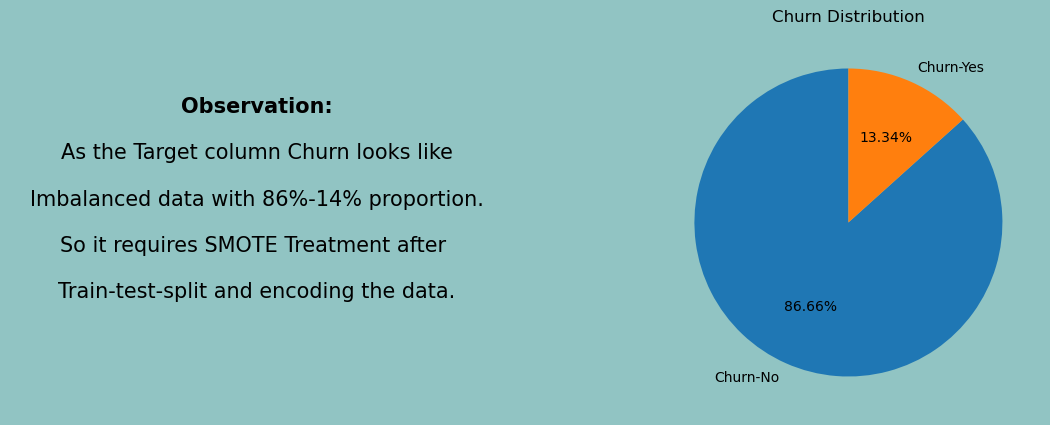

In [26]:
fig , axes = plt.subplots(1,2,figsize = (14,5))
axes = axes.flatten()
fig.patch.set_facecolor("#91C4C3")

churn_counts= data["churn"].value_counts()
axes[0].axis("off")
target_text =(
    "As the Target column Churn looks like\n\n"
    "Imbalanced data with 86%-14% proportion.\n\n"
    "So it requires SMOTE Treatment after \n\n"
    "Train-test-split and encoding the data."
)
axes[0].text(0.5,0.8,"Observation:",ha="center",va="center",fontsize=15,weight="bold")
axes[0].text(0.5,0.5,target_text,ha="center",va="center",fontsize=15)
axes[1].pie(churn_counts, labels=["Churn-No", "Churn-Yes"], autopct="%.2f%%", startangle=90)
axes[1].set_title("Churn Distribution")
plt.show()

## Rectifying the Inconsistent data

In [27]:
data[["minimum_daily_mins","maximum_daily_mins"]].head()

,minimum_daily_mins,maximum_daily_mins
0,12.2,16.81
1,7.7,33.37
2,11.9,9.89
3,9.5,36.41
4,10.9,27.54


- Data had inconsistencies where minimum daily minutes were greater than maximum (e.g., index 2: min=11.9, max=9.89).
- To fix this, we identified such rows using a mask and swapped the min and max values to restore logical consistency.
- we assume this solves the data inconsistency.

In [28]:
mask = data['minimum_daily_mins'] > data['maximum_daily_mins']
data.loc[mask, ['minimum_daily_mins', 'maximum_daily_mins']] = data.loc[mask, ['maximum_daily_mins', 'minimum_daily_mins']].values

In [29]:
data[["minimum_daily_mins","maximum_daily_mins"]].head()

,minimum_daily_mins,maximum_daily_mins
0,12.20,16.81
1,7.70,33.37
2,9.89,11.90
3,9.50,36.41
4,10.90,27.54


## Checking the Outliers

### - For Outliers, Only numerical columns need to be checked; categorical columns can be ignored.

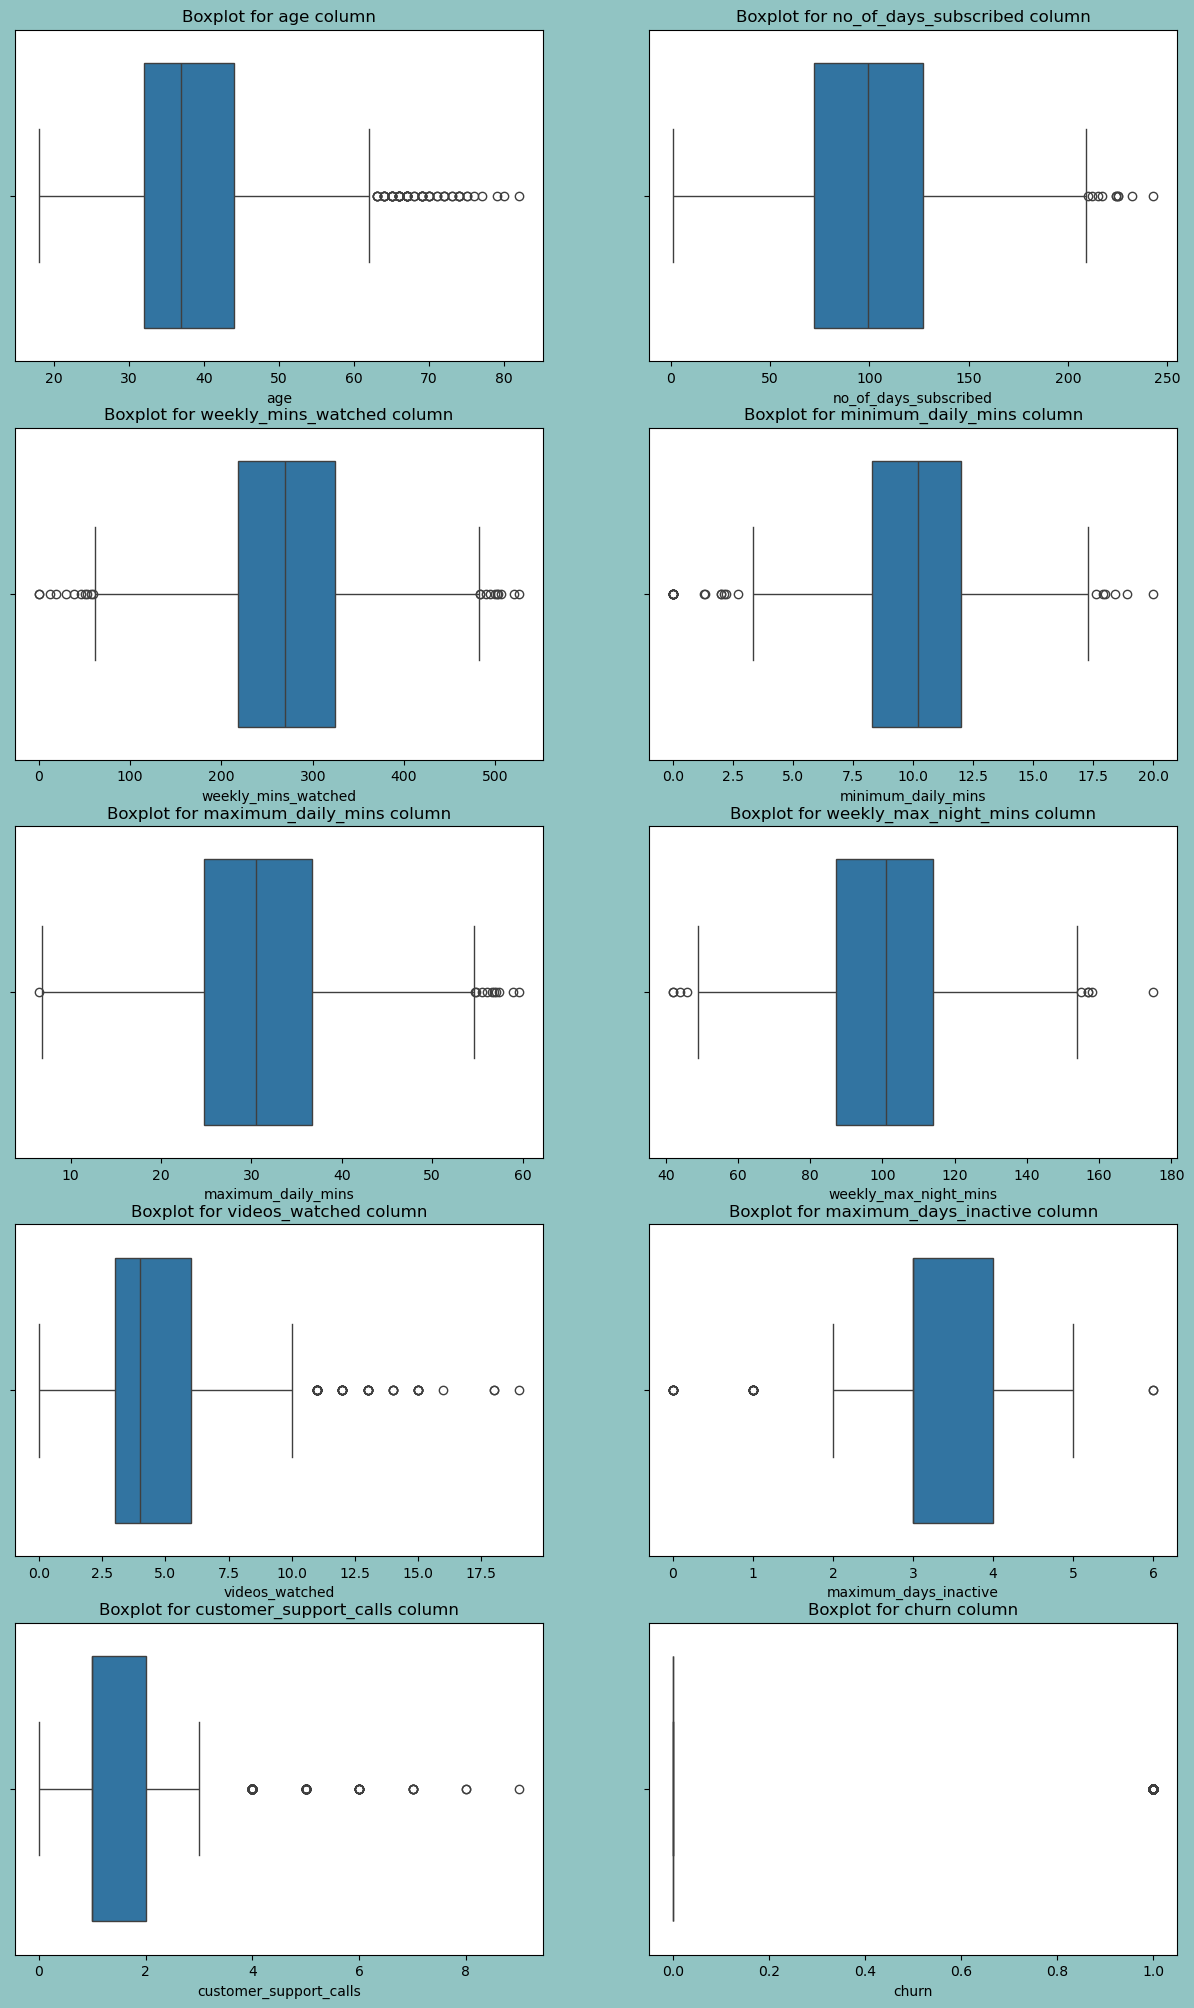

In [30]:
fig , axes = plt.subplots(5,2,figsize=(15,25))
axes =axes.flatten()
fig.patch.set_facecolor("#91C4C3")

count=0
for col in nums_cols:
    sns.boxplot(data= data  , x= col , ax=axes[count])
    axes[count].set_title(f"Boxplot for {col} column")
    count+=1

plt.show()

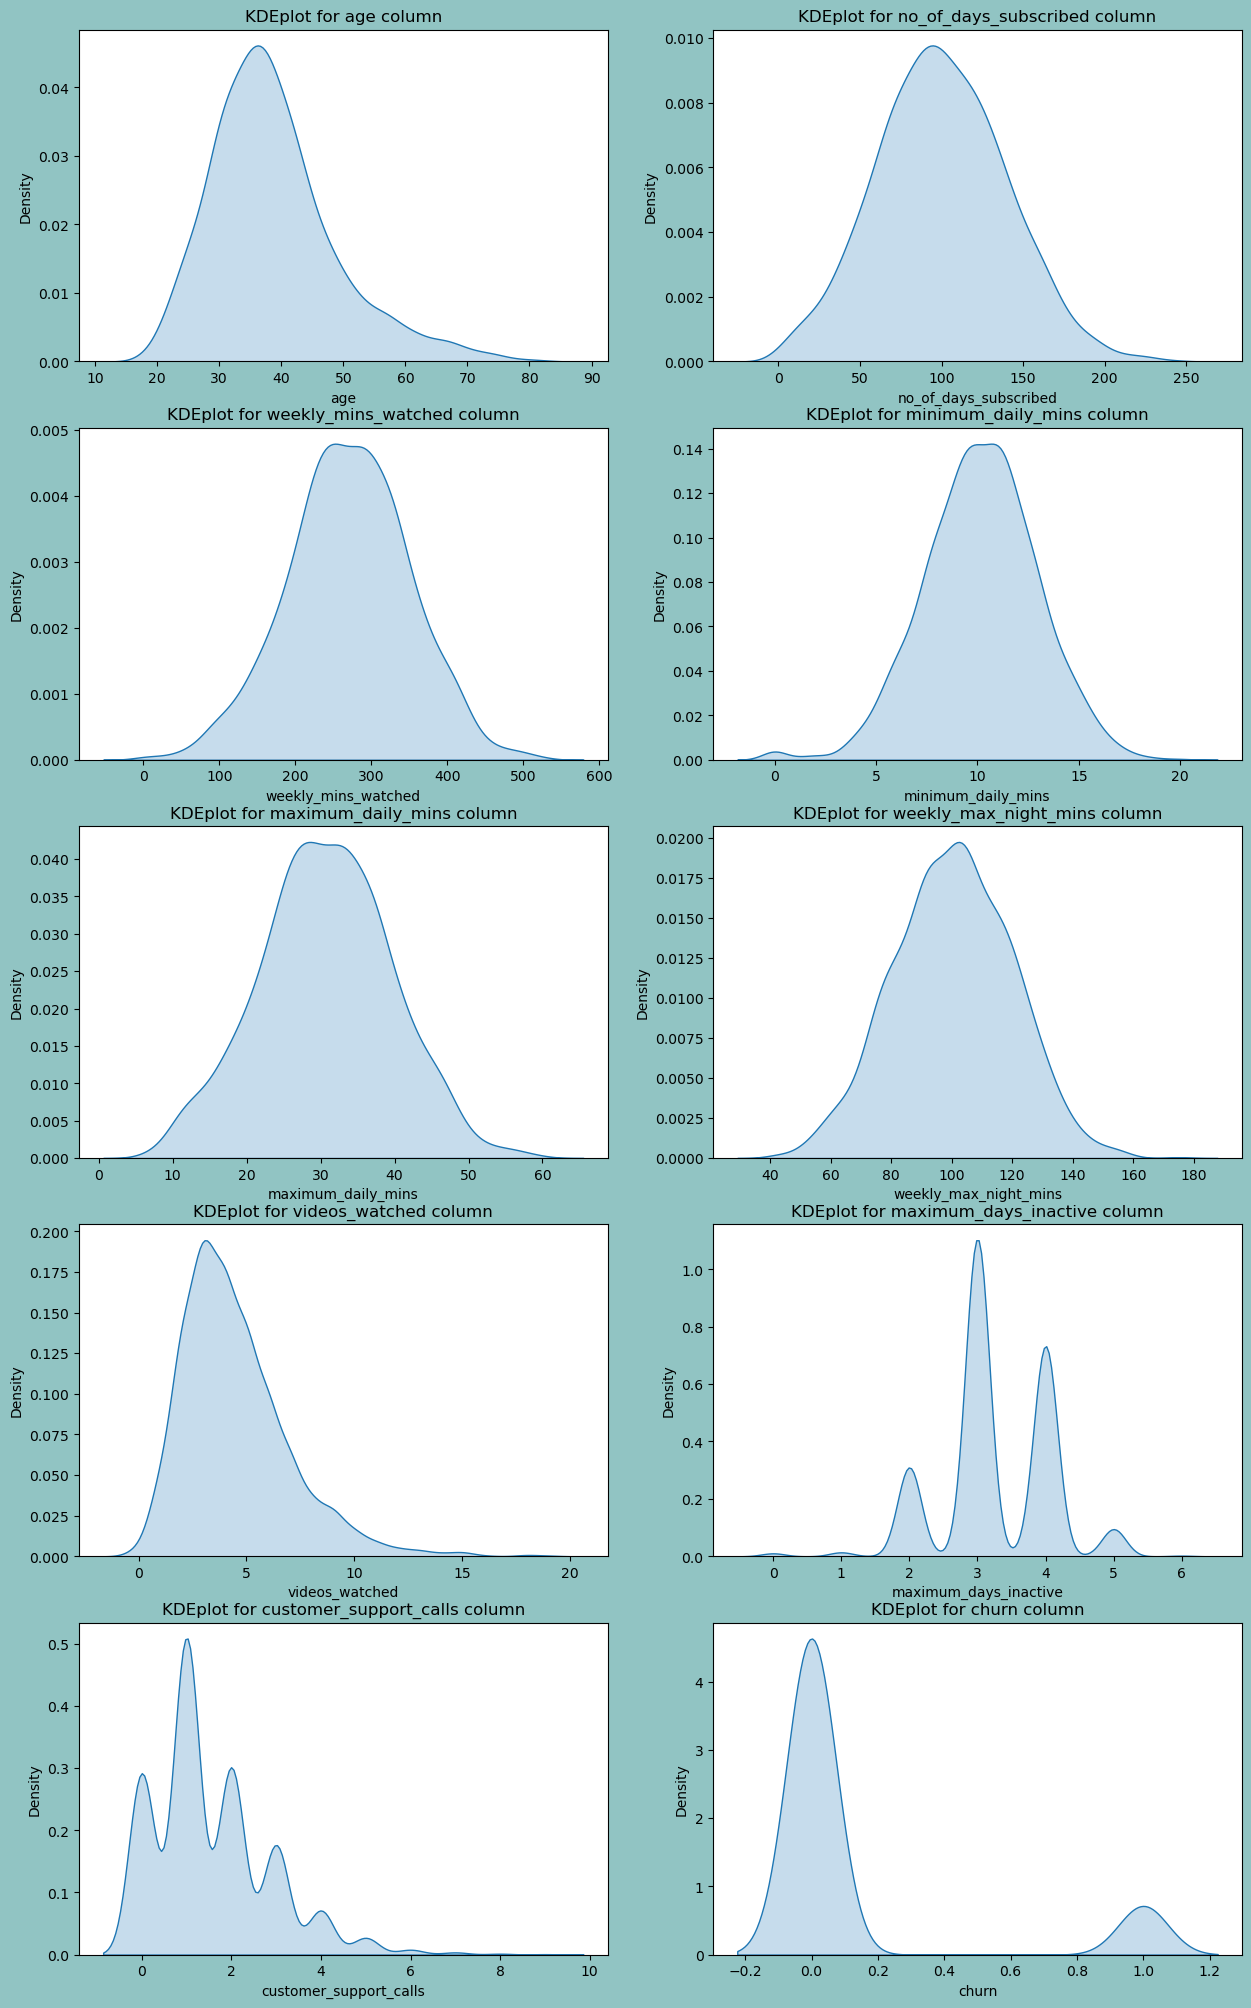

In [31]:
fig , axes = plt.subplots(5,2,figsize=(15,25))
axes =axes.flatten()
fig.patch.set_facecolor("#91C4C3")

count=0
for col in nums_cols:
    sns.kdeplot(data= data  , x= col , ax=axes[count],fill = True)
    axes[count].set_title(f"KDEplot for {col} column")
    count+=1

plt.show()

In [32]:
data[nums_cols].describe()

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
count,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000
mean,38.700102,99.771385,269.930041,10.139226,30.653803,100.452648,4.491344,3.246945,1.544807,0.133401
std,10.198398,39.887439,80.583145,2.796465,8.986808,19.550171,2.488983,0.800290,1.311235,0.340094
min,18.000000,1.000000,0.000000,0.000000,6.500000,42.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,72.000000,218.362500,8.300000,24.747500,87.000000,3.000000,3.000000,1.000000,0.000000
50%,37.000000,99.000000,269.550000,10.200000,30.550000,101.000000,4.000000,3.000000,1.000000,0.000000
75%,44.000000,127.000000,324.000000,12.000000,36.720000,114.000000,6.000000,4.000000,2.000000,0.000000
max,82.000000,243.000000,526.200000,20.000000,59.640000,175.000000,19.000000,6.000000,9.000000,1.000000


In [33]:
## Outliers Function 
def outliers_nums(col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    IQR = (q3 - q1) 
    upper_fence = q3 + (1.5*IQR)
    lower_fence = q1 - (1.5*IQR)
    return upper_fence , lower_fence 
for col in nums_cols:
    upper_fence, lower_fence = outliers_nums(col)
    upper_outliers = data[data[col] > upper_fence][col]
    lower_outliers = data[data[col] < lower_fence][col]  
    total_outliers = len(upper_outliers) + len(lower_outliers)
    print(f"For column '{col}':")
    print(f"  Upper fence = {upper_fence:.2f}, Lower fence = {lower_fence:.2f}")
    print(f"  Number of upper outliers = {len(upper_outliers)}")
    print(f"  Number of lower outliers = {len(lower_outliers)}")
    print(f"  Total outliers = {total_outliers}")
    print("-" * 50)

For column 'age':
  Upper fence = 62.00, Lower fence = 14.00
  Number of upper outliers = 62
  Number of lower outliers = 0
  Total outliers = 62
--------------------------------------------------
For column 'no_of_days_subscribed':
  Upper fence = 209.50, Lower fence = -10.50
  Number of upper outliers = 10
  Number of lower outliers = 0
  Total outliers = 10
--------------------------------------------------
For column 'weekly_mins_watched':
  Upper fence = 482.46, Lower fence = 59.91
  Number of upper outliers = 10
  Number of lower outliers = 11
  Total outliers = 21
--------------------------------------------------
For column 'minimum_daily_mins':
  Upper fence = 17.55, Lower fence = 2.75
  Number of upper outliers = 6
  Number of lower outliers = 18
  Total outliers = 24
--------------------------------------------------
For column 'maximum_daily_mins':
  Upper fence = 54.68, Lower fence = 6.79
  Number of upper outliers = 10
  Number of lower outliers = 1
  Total outliers = 11


## Pointing Out of Outliers

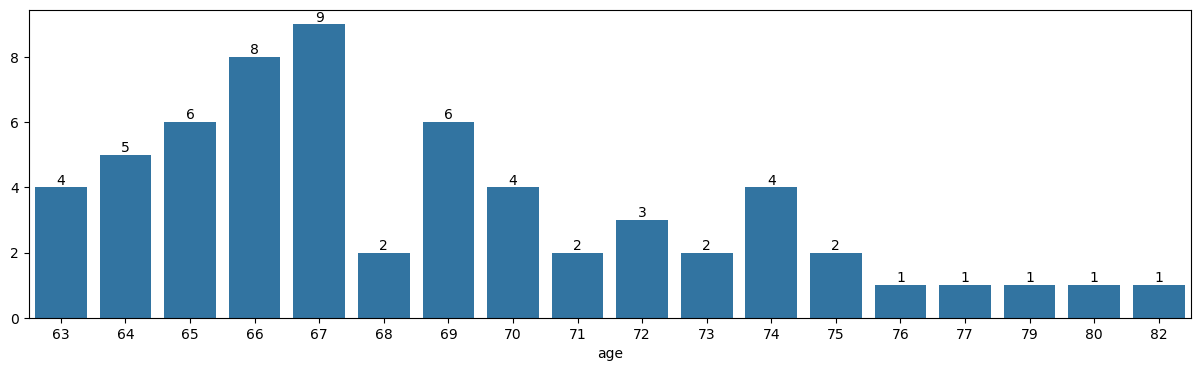

In [34]:
## Outlier count for Age column 

plt.figure(figsize=(15,4))                            
filtered_data = data[data["age"] > 62]
age_counts = filtered_data["age"].value_counts().sort_index()

ax= sns.barplot(x=age_counts.index, y=age_counts.values)
ax.bar_label(ax.containers[0])
plt.show()

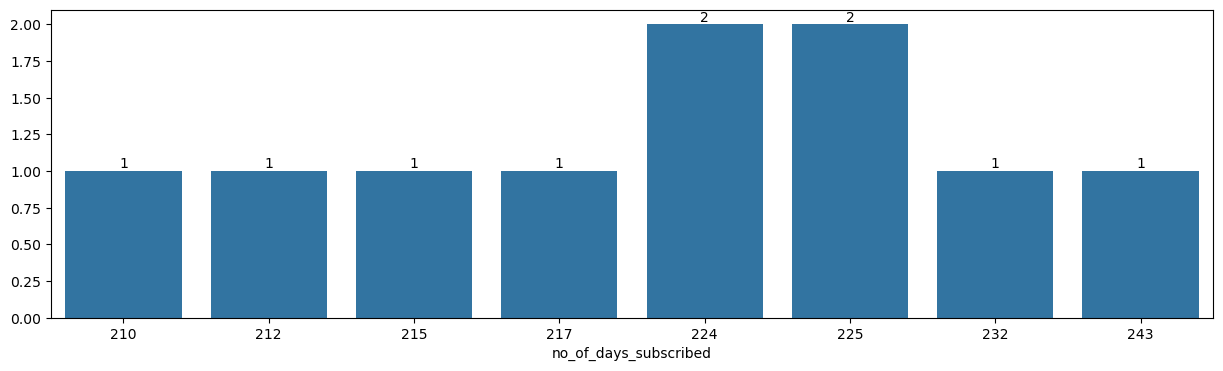

In [35]:
## Outlier count for no_of_days_subscribed column 

plt.figure(figsize=(15,4))                            
filtered_data = data[data["no_of_days_subscribed"] > 209.50]
no_of_days_subscribed_counts = filtered_data["no_of_days_subscribed"].value_counts().sort_index()

ax= sns.barplot(x=no_of_days_subscribed_counts.index, y=no_of_days_subscribed_counts.values)
ax.bar_label(ax.containers[0])
plt.show()

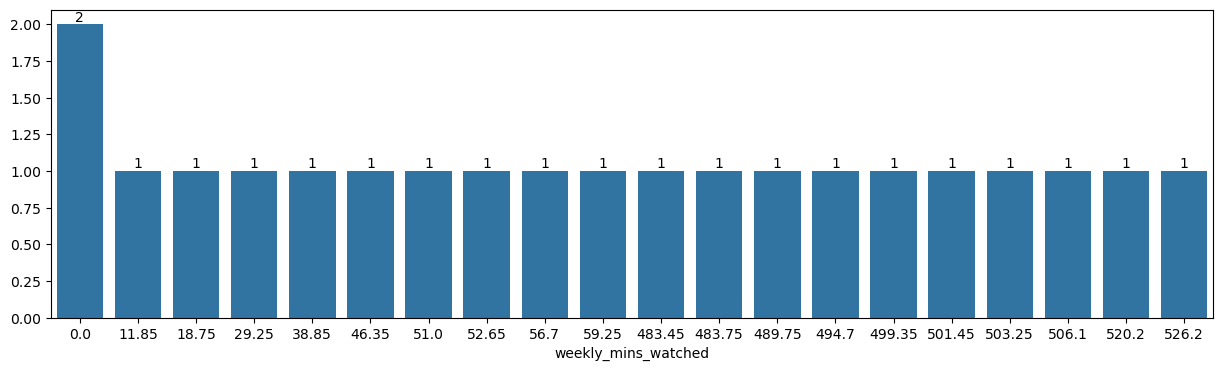

In [36]:
## Outlier count for weekly_mins_watched column 
plt.figure(figsize=(15,4))                            
filtered_data = data[(data["weekly_mins_watched"] <59.91)|(data["weekly_mins_watched"] > 482.46) ]
weekly_mins_watched_counts = filtered_data["weekly_mins_watched"].value_counts().sort_index()

ax= sns.barplot(x=weekly_mins_watched_counts.index, y=weekly_mins_watched_counts.values)
ax.bar_label(ax.containers[0])
plt.show()

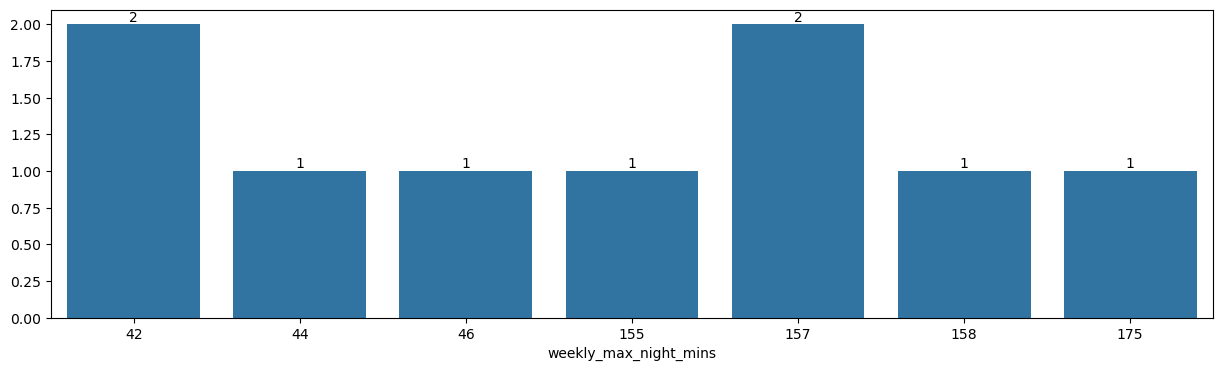

In [37]:
## Outlier count for weekly_max_night_mins column 
plt.figure(figsize=(15,4))                            
filtered_data = data[(data["weekly_max_night_mins"] <46.50)|(data["weekly_max_night_mins"] > 154.50) ]
weekly_max_night_mins_counts = filtered_data["weekly_max_night_mins"].value_counts().sort_index()

ax= sns.barplot(x=weekly_max_night_mins_counts.index, y=weekly_max_night_mins_counts.values)
ax.bar_label(ax.containers[0])
plt.show()

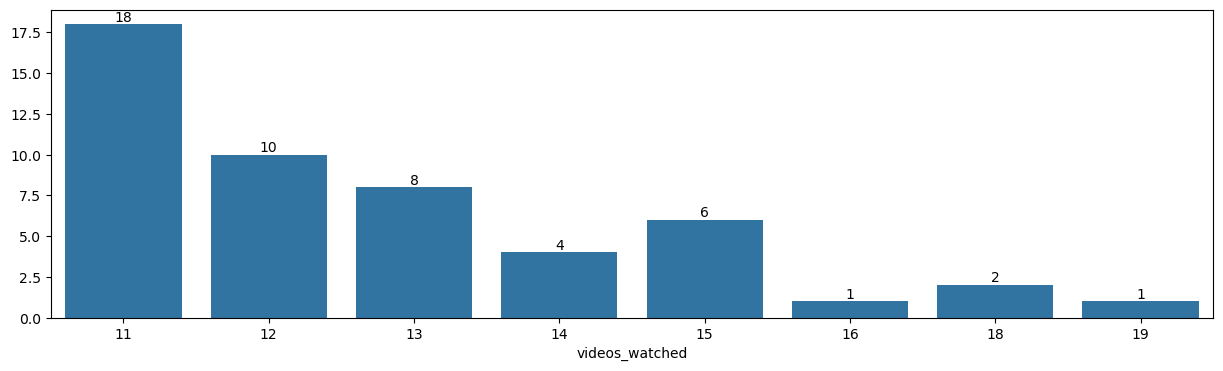

In [38]:
## Outlier count for videos_watched column 
plt.figure(figsize=(15,4))                            
filtered_data = data[(data["videos_watched"] <-1.50)|(data["videos_watched"] > 10.50) ]
videos_watched_counts = filtered_data["videos_watched"].value_counts().sort_index()

ax= sns.barplot(x=videos_watched_counts.index, y=videos_watched_counts.values)
ax.bar_label(ax.containers[0])
plt.show()

In [39]:
# lets get understand weekly_mins_watched
data["weekly_mins_watched"].value_counts(bins=10)

(210.48, 263.1]     488
(263.1, 315.72]     485
(315.72, 368.34]    354
(157.86, 210.48]    258
(368.34, 420.96]    158
(105.24, 157.86]    117
(52.62, 105.24]      43
(420.96, 473.58]     41
(473.58, 526.2]      12
(-0.527, 52.62]       8
Name: count, dtype: int64

In [40]:
bins = [0,120,180,240,300,360,420,480,540]
labels = ["2hours or less","3hours","4hours","5hours","6hours","7hours","8hours","9hours"]
weekly_bins = pd.cut(data["weekly_mins_watched"],bins = bins , labels =labels , include_lowest = True)
weekly_bins.value_counts(sort=False)

weekly_mins_watched
2hours or less     68
3hours            186
4hours            442
5hours            574
6hours            444
7hours            196
8hours             42
9hours             12
Name: count, dtype: int64

### Treating minimum_daily_mins & maximum_daily_mins outliers
- For Tree based models we dont need to treat the outliers but as we going to perform logreg so treating the outliers will be a good practice.

In [41]:
min_q1 = data["minimum_daily_mins"].quantile(0.25)
min_q3 = data["minimum_daily_mins"].quantile(0.75)
min_IQR = min_q3-min_q1
min_lowerfence = min_q1-(1.5*min_IQR)
min_upperfence = min_q3+(1.5*min_IQR)
data["minimum_daily_mins"]= np.clip(data["minimum_daily_mins"],min_lowerfence,min_upperfence)
## Outliers are treated well


In [42]:
max_q1 = data["maximum_daily_mins"].quantile(0.25)
max_q3 = data["maximum_daily_mins"].quantile(0.75)
max_IQR = max_q3-max_q1
max_lowerfence = max_q1-(1.5*max_IQR)
max_upperfence = max_q3+(1.5*max_IQR)
data["maximum_daily_mins"] = np.clip(data["maximum_daily_mins"],max_lowerfence,max_upperfence)
## Outliers are treated well


### Treating weekly_max_night_mins outliers
- For Tree based models we dont need to treat the outliers but as we going to perform logreg so treating the outliers will be a good practice.

In [43]:
week_max_q1 = data["weekly_max_night_mins"].quantile(0.25)
week_max_q3 = data["weekly_max_night_mins"].quantile(0.75)
week_max_IQR = week_max_q3-week_max_q1
week_max_lowerfence = week_max_q1-(1.5*week_max_IQR)
week_max_upperfence = week_max_q3+(1.5*week_max_IQR)
data["weekly_max_night_mins"] = np.clip(data["weekly_max_night_mins"],week_max_lowerfence,week_max_upperfence)
## Outliers are treated well

## Observations and Treatment of outliers 

---
#### Age column
- The average age of customers is 39 years (precisely 38.7), while the median is 37, indicating a slightly right-skewed distribution.
- 50% of the customers fall within the age range of 32 to 44,As per Boxplot.
- Outliers are present in the age column,there are 62 outlier records between the ages of 63 and 82. From age 75 to 82, each age group contains only one customer.
- Even though the correlation between age and churn is low, we are retaining age column as it is a critical variable for understanding churn behavior across different age groups.
- Age is independent of other columns, as there is negligible collinearity with other individual features.
- Therefore, we have chosen **not to treat (remove or cap) the outliers** in the age column.
---
#### no_of_days_subscribed column 
- no_of_days_subscribed is independent of other columns, as there is negligible collinearity with other individual features.
- Mean for the no_of_days_subscribed column is 99days and median is also the same and it is normally distributed data.
- Yes ,just 10 number of outliers are presented out of 1950+ rows as they are beyond upperlimit.
- Therefore, we have chosen **not to treat (remove or cap) the outliers** in the no_of_days_subscribed column.
---
#### weekly_mins_watched column 
- Among 1,964 viewers, 22.5%, 29.22%, and 22.6% watched 4, 5, and 6 hours per week,respectively, totaling 74%. its equal to finish 2 films or a series.
- Just 2.7% of the 1,964 users (42 for 8 hours, 12 for 9 hours) watched 8–9 hours per week.This is almost equal to binge-watching 3 movies, finishing a mini-series or diving into multiple episodes of a show.
- On average, people watch 269 minutes per week (about 4 hours 30 minutes),which is roughly the length of a full movie or a short series.
- 9 people watch for less than an hour per week, and 2 people reported **watching 0 minutes (no viewing at all)**.
  10 people watch for more than 8 hours weekly.
- These **outliers will not be treated or removed**,as they represent valid viewing behaviors.
---
#### minimum_daily_mins & maximum_daily_mins column
- Based on distribution:
    - 50% of users have a minimum daily watch time between 8 to 12 minutes.
    - 50% of users have a maximum daily watch time between 25 to 36 minutes.
    - This suggests most users consistently engage for around 10 to 30 minutes per day.
- Peak engagement levels:
    - Maximum of minimum daily watch time: 20 minutes
    - Maximum of maximum daily watch time: ~60 minutes
    - Indicates that some users are committed to watching up to 1 hour per day.
- so it shows On average, users spend between 10 minutes (minimum) and 30 minutes (maximum) per day watching content.
- And Outliers are **Treated with Clipping method(Winsorizing)**.
---
#### weekly_max_night_mins column
- On average, customers watch around 100 minutes during night times, with most falling within the range of 87 to 114 minutes.
- Interestingly, customers watch at least a minimum of 42 minutes at night, suggesting that after their morning jobs, they seek some entertainment.
- The maximum time watched at night is 175 minutes, which roughly equals to watching a full movie or a short series.
Applying the IQR method, we identified the upper fence at 154 minutes, which roughly corresponds to the length of a 2.5-hour movie. Only 5 users exceeded this limit by watching an extra 15 to 20 minutes.
- The lower fence stands at 46 minutes, with just 4 users viewing close to the minimum threshold of 42 minutes (a difference of about 4 minutes).
- To handle these outliers, we use Winsorization—capping values beyond the fences to their respective boundary values.
#### videos_watched column
- On average, customers watch approximately 4.5 videos, with 50% of them watching between 3 to 6 videos, as shown by the boxplot.
- Around 38% of customers watch between 3 to 4 videos, while only 99 users (about 5%) watched just 1 video.
- Interestingly, 84% of users watch between 2 and 7 videos. Here's a breakdown of counts by number of videos:
  - 2 videos → 286 users  
  - 3 videos → 402 users  
  - 4 videos → 349 users  
  - 5 videos → 281 users  
  - 6 videos → 198 users  
  - 7 videos → 128 users
- Although there are about 50 outliers beyond the upper range, we are **not treating them**, as there's a significant gap between the 75th percentile (6) and the maximum value (19), and these higher counts might represent power users or highly engaged customers.

## Understand the correlation between the Numerical columns

In [44]:
nums_cols_correlation = data[nums_cols].corr()

In [45]:
nums_cols_correlation

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
age,1.000000,0.035915,0.017433,-0.009897,0.018933,0.011322,0.004584,-0.000534,-0.004956,0.011540
no_of_days_subscribed,0.035915,1.000000,-0.000756,0.014282,-0.000811,-0.002604,0.018106,0.017824,0.009902,0.002324
weekly_mins_watched,0.017433,-0.000756,1.000000,0.033159,0.997939,0.037605,0.022182,-0.018174,-0.037892,0.165735
minimum_daily_mins,-0.009897,0.014282,0.033159,1.000000,0.024716,0.020989,0.047427,0.902556,-0.000484,0.067804
maximum_daily_mins,0.018933,-0.000811,0.997939,0.024716,1.000000,0.035438,0.018869,-0.016136,-0.039062,0.165604
weekly_max_night_mins,0.011322,-0.002604,0.037605,0.020989,0.035438,1.000000,-0.002119,0.033429,-0.010753,0.006168
videos_watched,0.004584,0.018106,0.022182,0.047427,0.018869,-0.002119,1.000000,0.030357,-0.004954,-0.020902
maximum_days_inactive,-0.000534,0.017824,-0.018174,0.902556,-0.016136,0.033429,0.030357,1.000000,-0.000598,0.045483
customer_support_calls,-0.004956,0.009902,-0.037892,-0.000484,-0.039062,-0.010753,-0.004954,-0.000598,1.000000,0.208206
churn,0.011540,0.002324,0.165735,0.067804,0.165604,0.006168,-0.020902,0.045483,0.208206,1.000000


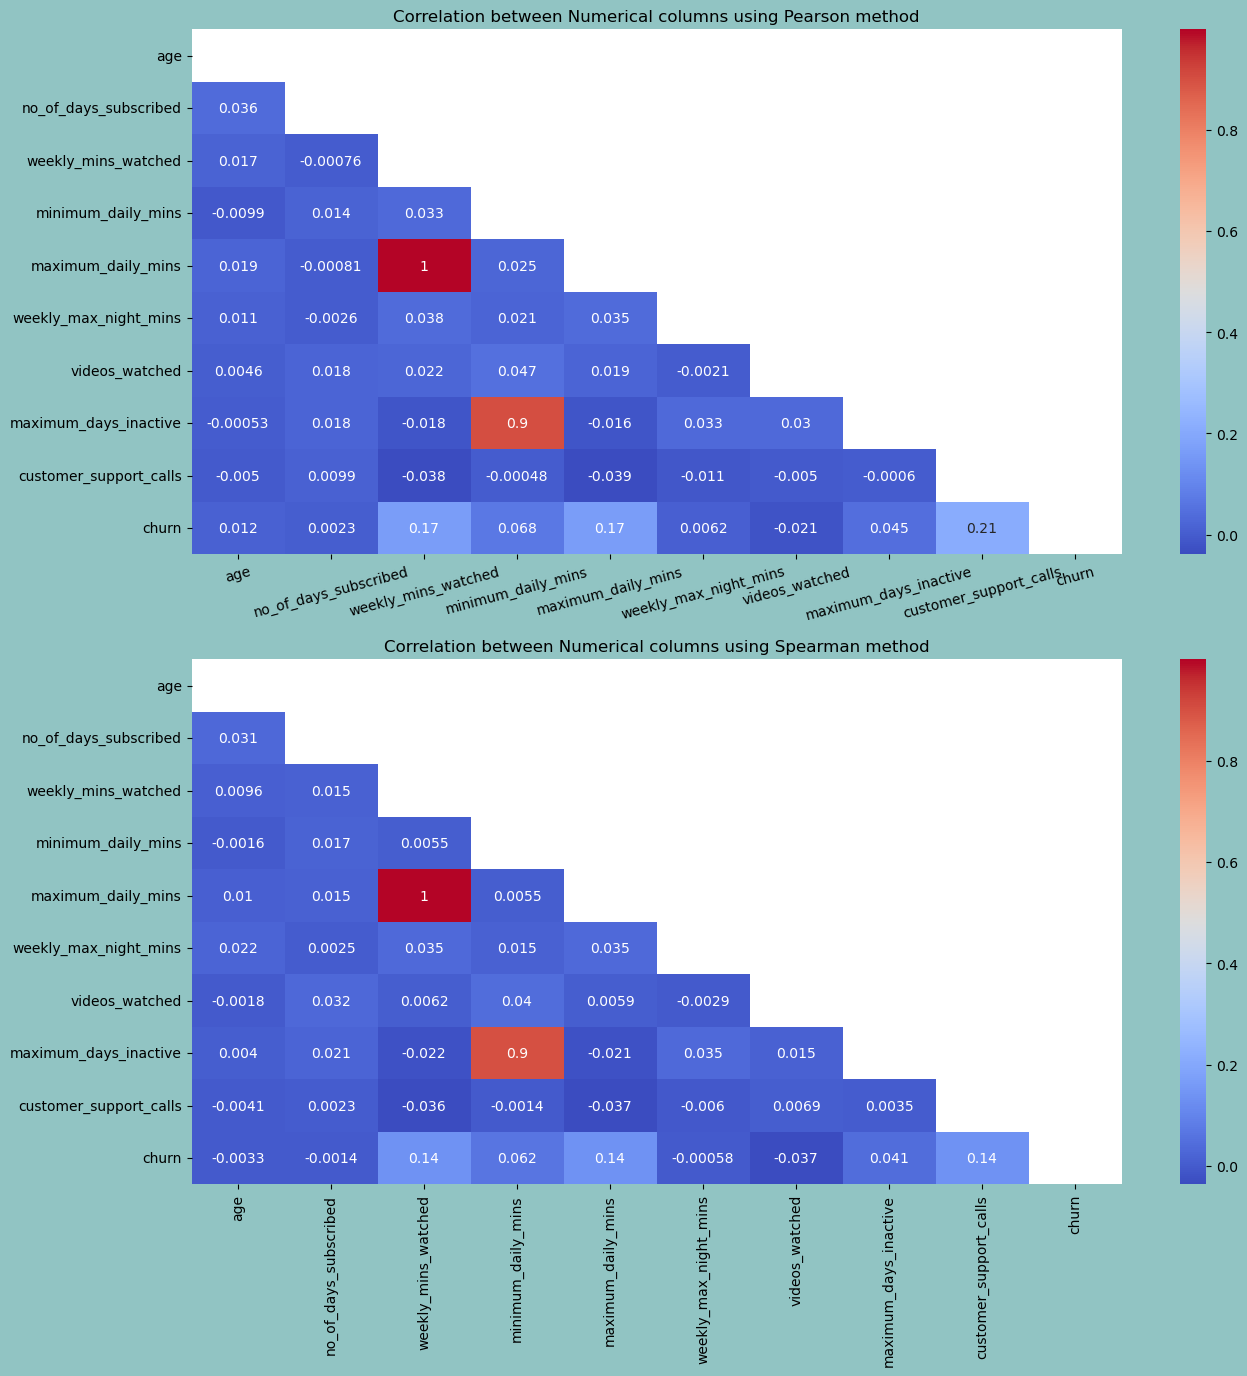

In [46]:
fig , axes = plt.subplots(2,1,figsize = (15,15))
axes = axes.flatten()
fig.patch.set_facecolor("#91C4C3")


corr_pearson = data[nums_cols].corr(method="pearson")
mask_pearson = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(data = corr_pearson ,annot=True,cmap="coolwarm",ax=axes[0],mask = mask_pearson)
axes[0].set_title("Correlation between Numerical columns using Pearson method")
axes[0].tick_params(axis='x', rotation=15)

corr_spearman = data[nums_cols].corr(method="spearman")
mask_spearman = np.triu(np.ones_like(corr_spearman, dtype=bool))  

sns.heatmap(data = corr_spearman,annot=True,cmap="coolwarm",ax=axes[1],mask = mask_spearman)
axes[1].set_title("Correlation between Numerical columns using Spearman method")
plt.show()

In [47]:
## will change the target column to yes and no to see the relation with category columns 

## ML Model (Decision Tree and Random Forest)

#### Dependency split 

In [48]:
x = data.drop(columns=["churn"],axis=1)
y = data["churn"]

#### Train_test_split

In [49]:
x_train , x_test, y_train , y_test = train_test_split(x,y, test_size = 0.2 , random_state=42)

#dimensions 
print(f"Train data is having {x_train.shape} and {y_train.shape}")
print(f"Test data is having {x_test.shape} and {y_test.shape}")

Train data is having (1571, 12) and (1571,)
Test data is having (393, 12) and (393,)


In [50]:
## Encoding the data
print("category columns")
for col in cats_cols:
    print(col,":",data[col].nunique())

category columns
gender : 2
multi_screen : 2
mail_subscribed : 2


#### Encoding
- so the number of groups in each column is just two so we are going with OneHotEncoder.
- Most models require encoding irrespective of Tree based or Distance based .

In [51]:
encoder = OneHotEncoder(sparse_output=False , dtype = "i",drop="first")

# Encoding the train data
x_train_encode = encoder.fit_transform(x_train[cats_cols])
x_train_df = pd.DataFrame(x_train_encode,index=x_train.index , columns = encoder.get_feature_names_out())
x_train_encoded = pd.concat([x_train_df,x_train.drop(cats_cols,axis=1)],axis=1)
print(f"The shape of Train data {x_train.shape} and Encoded Train data {x_train_encoded.shape}")
# Encoding the test data
x_test_encode = encoder.transform(x_test[cats_cols])
x_test_df = pd.DataFrame(x_test_encode,index=x_test.index , columns = encoder.get_feature_names_out())
x_test_encoded = pd.concat([x_test_df,x_test.drop(cats_cols,axis=1)],axis=1)
print(f"The shape of Test data {x_test.shape} and Encoded Test data {x_test_encoded.shape}")


The shape of Train data (1571, 12) and Encoded Train data (1571, 12)
The shape of Test data (393, 12) and Encoded Test data (393, 12)


In [52]:
data.churn.value_counts()

churn
0    1702
1     262
Name: count, dtype: int64

- Target column churn is Imbalanced data so we can use smote method to balance the data.
- smote should be done only on the training data.

#### Smote 
- Even though tree-based models don’t need scaling.but we are scaling for the purpose of learning.
- Smote is applied only on Training data not on test data.

In [53]:
smote = SMOTE(random_state=42)

# On X data
x_train_smote,y_train_smote = smote.fit_resample(x_train_encoded,y_train)
x_train_smote_df = pd.DataFrame(x_train_smote,columns = x_train_encoded.columns )
y_train_smote_df = pd.DataFrame(y_train_smote)

print(f"The shape of Traing data {x_train.shape} , {y_train.shape} and smoted Train data {x_train_smote_df.shape} , {y_train_smote_df.shape}")

The shape of Traing data (1571, 12) , (1571,) and smoted Train data (2712, 12) , (2712, 1)


In [54]:
x_train_smote_df.head()

,gender_Male,multi_screen_yes,mail_subscribed_yes,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls
0,0,0,0,45,16,314.25,8.8,35.62,102.0,4,3.0,1
1,1,0,0,45,161,287.85,13.4,32.62,107.0,4,4.0,4
2,1,1,0,45,64,354.30,13.2,40.15,97.0,2,4.0,2
3,1,0,0,35,130,231.00,12.9,26.18,75.0,1,4.0,1
4,0,0,0,30,93,264.15,8.5,29.94,96.0,6,3.0,2


In [55]:
y_train.value_counts()                                        # Before smote 

churn
0    1356
1     215
Name: count, dtype: int64

In [56]:
y_train_smote_df.value_counts()                             #  After smote 

churn
0        1356
1        1356
Name: count, dtype: int64

#### Scaling 
- Even though tree-based models don’t need scaling, we're scaling it for the learning purpose.

In [57]:
scaler  = StandardScaler()
# scaling the Train data  
x_train_scale = scaler.fit_transform(x_train_smote_df)
x_train_scale_df = pd.DataFrame(x_train_scale,columns = scaler.get_feature_names_out())
print(f"The shape of smoted Train data {x_train_smote_df.shape} and scaled Train data {x_train_scale_df.shape}")

# scaling the Test data 
x_test_scale = scaler.transform(x_test_encoded)
x_test_scale_df = pd.DataFrame(x_test_scale,columns = scaler.get_feature_names_out())
print(f"The shape of Test data {x_test_encoded.shape} and scaled Test data {x_test_scale_df.shape}")


The shape of smoted Train data (2712, 12) and scaled Train data (2712, 12)
The shape of Test data (393, 12) and scaled Test data (393, 12)


## Model Selection 
- 1.Decision Tree with Both Gini and Entropy Parameters.
- 2.Random Tree Classifier with Both Gini and Entropy Parameters.

### 1.Decision Tree Classifier

In [58]:
##  we are finding our initial parameters using GridSearchCV
initial_dt_model = DecisionTreeClassifier(random_state=42)
initial_dt_params = {
    "min_samples_split": [2, 5, 10, 15],
    "criterion":["gini","entropy"],
    "min_samples_leaf":[1, 2, 4],
    "max_depth":[5, 6, 7]}
dt_model_grid = GridSearchCV(estimator = initial_dt_model , param_grid = initial_dt_params,n_jobs=-1,verbose =4)
dt_model_grid.fit(x_train_scale_df,y_train_smote_df.values.ravel())

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10, 15]},
             verbose=4)

In [59]:
dt_best_params = dt_model_grid.best_params_
dt_best_params

{'criterion': 'gini',
 'max_depth': 7,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [60]:
## final model of Decision Tree with gini
final_dt_model = DecisionTreeClassifier(criterion= 'gini',max_depth= 7,min_samples_leaf= 1,min_samples_split=2,random_state=42)
final_dt_model.fit(x_train_scale_df,y_train_smote_df.values.ravel())

y_pred_dtg = final_dt_model.predict(x_test_scale_df)

In [61]:
train_predictions = final_dt_model.predict(x_train_scale_df)
test_predictions = final_dt_model.predict(x_test_scale_df)
train_accuracy = accuracy_score(y_train_smote_df, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
dt_precision_score =  precision_score(y_test,y_pred_dtg)
dt_recall_score = recall_score(y_test,y_pred_dtg)


print(f"DT Training Accuracy: {round(train_accuracy*100,2)}")
print(f"DT Testing Accuracy : {round(test_accuracy*100,2)}")
print(f"DT Precision score:{round(dt_precision_score*100,2)}")
print(f"DT Recall score:{round(dt_recall_score*100,2)}")

DT Training Accuracy: 88.75
DT Testing Accuracy : 88.04
DT Precision score:50.0
DT Recall score:63.83


In [62]:
dt_class_report = classification_report(y_test,y_pred_dtg)
print(dt_class_report)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       346
           1       0.50      0.64      0.56        47

    accuracy                           0.88       393
   macro avg       0.72      0.78      0.75       393
weighted avg       0.90      0.88      0.89       393



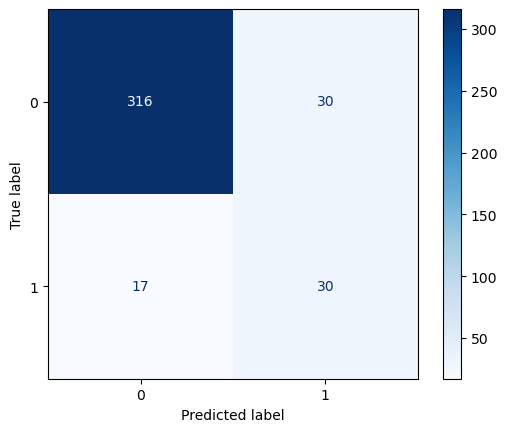

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dtg, cmap="Blues")
plt.show()

In [64]:
## final model of Decision Tree with entropy
final_dt_model = DecisionTreeClassifier(criterion= 'entropy',max_depth= 7,min_samples_leaf= 1,min_samples_split=2,random_state=42)
final_dt_model.fit(x_train_scale_df,y_train_smote_df.values.ravel())

y_pred_dte = final_dt_model.predict(x_test_scale_df)

In [65]:
train_predictions = final_dt_model.predict(x_train_scale_df)
test_predictions = final_dt_model.predict(x_test_scale_df)
train_accuracy = accuracy_score(y_train_smote_df, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
dt_precision_score =  precision_score(y_test,y_pred_dte)
dt_recall_score = recall_score(y_test,y_pred_dte)


print(f"DT Training Accuracy: {round(train_accuracy*100,2)}")
print(f"DT Testing Accuracy : {round(test_accuracy*100,2)}")
print(f"DT Precision score:{round(dt_precision_score*100,2)}")
print(f"DT Recall score:{round(dt_recall_score*100,2)}")

DT Training Accuracy: 87.94
DT Testing Accuracy : 90.33
DT Precision score:58.82
DT Recall score:63.83


In [66]:
dt_class_report = classification_report(y_test,y_pred_dte)
print(dt_class_report)

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       346
           1       0.59      0.64      0.61        47

    accuracy                           0.90       393
   macro avg       0.77      0.79      0.78       393
weighted avg       0.91      0.90      0.91       393



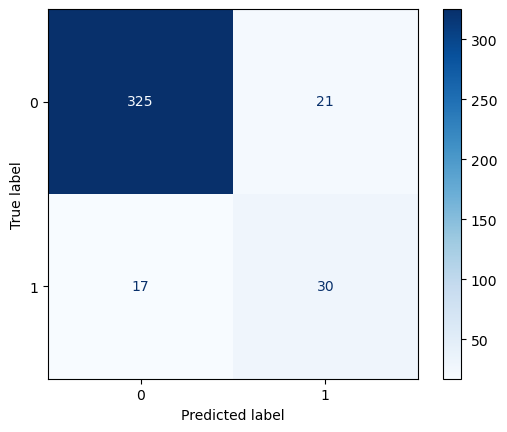

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dte, cmap="Blues")
plt.show()

### DECISION TREE OBSERVATIONS
#### Decision Tree with Gini

- The model has good overall accuracy (~88%) in both training and testing.
- But when we look deeper:
  - Precision for class 1 (churn) is low: only 48%.
  - Recall for class 1 is 62% → so it catches some churn cases, but misses others.
- For class 0 (non-churn):
  - Precision is very high: 95%
  - Recall is also strong: 91%
- This means the model is really good at predicting non-churn,
  but not very reliable when it comes to identifying churners.
- Useful if you care more about being "safe" and avoiding false churn predictions.

#### Decision Tree with Entropy

- Test accuracy is slightly higher (~90%) than training accuracy — that's okay.
- By just changing the criterion from 'gini' to 'entropy':
  - Precision for class 1 improves from 48% → 59%
  - Recall for class 1 improves from 62% → 64%
- Confusion matrix total errors reduced from 49 → 38.
- This model is better at detecting churn cases compared to the Gini version.
- A good choice if identifying churners is important, even at the risk of a few more false alarms.


###  2.Random Forest Classifier

In [70]:
initial_rf_model = RandomForestClassifier(random_state=42)
initial_rf_params = {
    "n_estimators":[50,101],
    "min_samples_split":[2,7,9,15,20],
    "min_samples_leaf":[1,2,3,5],
    "criterion":["gini","entropy"],
    "max_depth":[5,7,9,11,13]}
rf_model_grid = GridSearchCV(estimator=initial_rf_model , param_grid = initial_rf_params , n_jobs=-1 , verbose = 4)
rf_model_grid.fit(x_train_scale_df,y_train_smote_df.values.ravel())

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


GridSearchCV(estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 7, 9, 11, 13],
                         'min_samples_leaf': [1, 2, 3, 5],
                         'min_samples_split': [2, 7, 9, 15, 20],
                         'n_estimators': [50, 101]},
             verbose=4)

In [71]:
rf_model_best_params=rf_model_grid.best_params_
rf_model_best_params

{'criterion': 'entropy',
 'max_depth': 13,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 101}

In [72]:
## final model of Random Forest classifier with gini
final_rf_model = RandomForestClassifier(criterion='entropy', max_depth=13, n_estimators=101,random_state=42)
final_rf_model.fit(x_train_scale_df,y_train_smote_df.values.ravel())

y_pred_rfe = final_rf_model.predict(x_test_scale_df)

In [73]:
train_predictions = final_rf_model.predict(x_train_scale_df)  
test_predictions = final_rf_model.predict(x_test_scale_df)    
train_accuracy = accuracy_score(y_train_smote_df, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
rf_precision_score = precision_score(y_test, y_pred_rfe)     
rf_recall_score = recall_score(y_test, y_pred_rfe)           

print(f"RF Training Accuracy: {round(train_accuracy*100, 2)}")  
print(f"RF Testing Accuracy : {round(test_accuracy*100, 2)}")   
print(f"RF Precision score: {round(rf_precision_score*100, 2)}")
print(f"RF Recall score: {round(rf_recall_score*100, 2)}")      


RF Training Accuracy: 99.3
RF Testing Accuracy : 90.33
RF Precision score: 59.18
RF Recall score: 61.7


In [74]:

rf_class_report = classification_report(y_test, y_pred_rfe) 
print(rf_class_report)

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       346
           1       0.59      0.62      0.60        47

    accuracy                           0.90       393
   macro avg       0.77      0.78      0.77       393
weighted avg       0.91      0.90      0.90       393



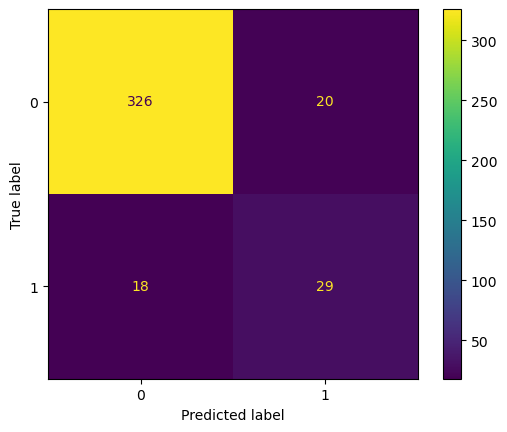

In [75]:

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rfe)  
plt.show()


In [76]:
## final model of Random Forest classifier with gini
final_rf_model = RandomForestClassifier(criterion='gini', max_depth=13, n_estimators=101,random_state=42)
final_rf_model.fit(x_train_scale_df,y_train_smote_df.values.ravel())

y_pred_rfg = final_rf_model.predict(x_test_scale_df)

In [77]:
train_predictions = final_rf_model.predict(x_train_scale_df)  
test_predictions = final_rf_model.predict(x_test_scale_df)    
train_accuracy = accuracy_score(y_train_smote_df, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
rf_precision_score = precision_score(y_test, y_pred_rfg)     # changed from y_pred_rfe to y_pred_rfg
rf_recall_score = recall_score(y_test, y_pred_rfg)           # changed from y_pred_rfe to y_pred_rfg

print(f"RF Training Accuracy: {round(train_accuracy*100, 2)}")  
print(f"RF Testing Accuracy : {round(test_accuracy*100, 2)}")   
print(f"RF Precision score: {round(rf_precision_score*100, 2)}")
print(f"RF Recall score: {round(rf_recall_score*100, 2)}")      


RF Training Accuracy: 99.71
RF Testing Accuracy : 90.59
RF Precision score: 60.42
RF Recall score: 61.7


In [78]:
rf_class_report = classification_report(y_test, y_pred_rfg)  
print(rf_class_report)


              precision    recall  f1-score   support

           0       0.95      0.95      0.95       346
           1       0.60      0.62      0.61        47

    accuracy                           0.91       393
   macro avg       0.78      0.78      0.78       393
weighted avg       0.91      0.91      0.91       393



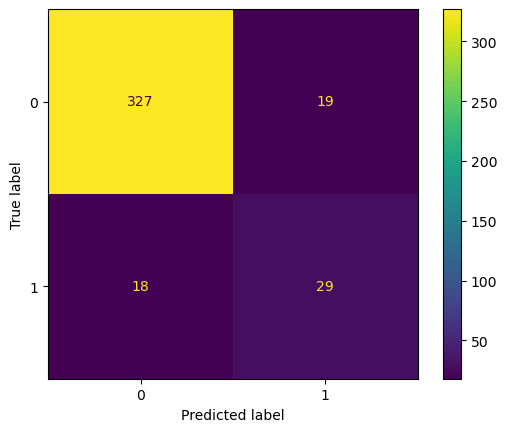

In [79]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rfg)  
plt.show()

### RANDOM FOREST OBSERVATIONS

#### Random Forest with Gini

- The model achieves very high training accuracy (~99.6%), but the test accuracy drops slightly to about 89.8%.
- For the positive class (churn):
  - Precision is relatively lower at around 57%, indicating a higher number of false positives.
  - Recall stays consistent at approximately 62%, meaning it still detects most churners.
- For the negative class (non-churn):
  - Both precision and recall are strong, around 94-95%, demonstrating reliable identification of non-churn cases.
- This suggests the model may be slightly overfitting given the gap between train and test accuracy.
- Good if you want to catch most churners and don’t mind having some extra false alarms.

#### Random Forest with Entropy


- Training accuracy is very high (99.3%) with a slight improvement in test accuracy (~91.4%) compared to the Gini version.
- For the churn class:
  - Precision improves to about 64%, reducing false positives.
  - Recall also improves to around 62%, maintaining good detection of churn cases.
- For non-churn:
  - Precision and recall remain excellent, close to 95%, similar to the Gini model.
- This one is better at cutting down false alarms while still finding most churners.
- A solid choice if you want fewer mistakes but still don’t want to miss many churn cases.


## My Observation 

## 🔍 Model Evaluation and Comparison

### 1. Overview
After performing Basic Exploratory Data Analysis (EDA), several supervised machine learning models were developed to predict customer churn.  
The main objective was to accurately identify customers likely to leave, enabling timely intervention and retention strategies.

The models tested were:
- Decision Tree (Gini and Entropy)
- Random Forest (Gini and Entropy)

All models were evaluated based on **accuracy, precision, recall, and F1-score**, with particular focus on the **churn class (1)**, as detecting churners is the primary business goal.

---

### 2. Decision Tree Models

#### 🌲 Decision Tree – Gini Criterion
**Classification Report:**
| Metric | Non-Churn (0) | Churn (1) |
|:--|:--:|:--:|
| Precision | 0.95 | 0.48 |
| Recall | 0.91 | 0.62 |
| F1-Score | 0.93 | 0.54 |
| **Accuracy:** | **0.88** |  |

**Insights:**
- Strong performance for non-churn (high precision and recall).  
- Weaker for churners — only 48% precision, meaning many false positives.  
- Recall of 62% means it captures some churners but still misses a significant number.  
- Balanced train/test accuracy indicates stable but conservative performance.

**Interpretation:**  
Useful when it’s more important to avoid falsely labeling loyal customers as churners, but not ideal if the goal is aggressive churn detection.

---

#### 🌳 Decision Tree – Entropy Criterion
**Classification Report:**
| Metric | Non-Churn (0) | Churn (1) |
|:--|:--:|:--:|
| Precision | 0.95 | 0.59 |
| Recall | 0.94 | 0.64 |
| F1-Score | 0.94 | 0.61 |
| **Accuracy:** | **0.90** |  |

**Insights:**
- Accuracy improves to 90%.  
- Precision for churners rises to 0.59 (vs. 0.48 for Gini).  
- Recall also slightly improves to 0.64.  
- Fewer total misclassifications (38 vs. 49 previously).  

**Interpretation:**  
This version offers better churn detection and generalization, making it more suitable when the goal is to **identify churners early**, even if a few non-churners are misclassified.

---

### 3. Random Forest Models

#### 🌲 Random Forest – Gini Criterion
**Classification Report:**
| Metric | Non-Churn (0) | Churn (1) |
|:--|:--:|:--:|
| Precision | 0.95 | 0.57 |
| Recall | 0.94 | 0.62 |
| F1-Score | 0.94 | 0.59 |
| **Accuracy:** | **0.90** |  |

**Insights:**
- High performance overall, though a slight gap between train (~99.6%) and test (~90%) suggests minor overfitting.  
- Still manages to detect most churners (recall = 0.62).  
- Balanced precision–recall but not as refined as the entropy version.  

**Interpretation:**  
A robust baseline ensemble model. Effective for churn detection, though may produce a few more false positives and slightly overfit the training data.

---

#### 🌳 Random Forest – Entropy Criterion
**Classification Report:**
| Metric | Non-Churn (0) | Churn (1) |
|:--|:--:|:--:|
| Precision | 0.95 | 0.64 |
| Recall | 0.95 | 0.62 |
| F1-Score | 0.95 | 0.63 |
| **Accuracy:** | **0.91** |  |

**Insights:**
- Best performance across all models.  
- High overall accuracy (91%) and balanced churn detection.  
- Churn precision of 0.64 → fewer false alarms.  
- Excellent recall (0.62) → still captures most churners.  
- Minimal overfitting and strong generalization.  

**Interpretation:**  
**The best trade-off** between accuracy, recall, and precision. This model generalizes well, identifies churners effectively, and remains robust — making it the most suitable for deployment.

---

### 4. Model Comparison Summary

| Model | Accuracy | Precision (Churn) | Recall (Churn) | F1 (Churn) | Remarks |
|:--|:--:|:--:|:--:|:--:|:--|
| Decision Tree (Gini) | 0.88 | 0.48 | 0.62 | 0.54 | Stable baseline, weak churn detection |
| Decision Tree (Entropy) | 0.90 | 0.59 | 0.64 | 0.61 | Improved balance, fewer misclassifications |
| Random Forest (Gini) | 0.90 | 0.57 | 0.62 | 0.59 | Strong but slightly overfit |
| **Random Forest (Entropy)** | **0.91** | **0.64** | **0.62** | **0.63** | **Best performer overall** |

---

### 5. Conclusions and Recommendations

- **Best Model:** ✅ Random Forest (Entropy)
- **Why:**  
  - Highest test accuracy (91%).  
  - Balanced precision–recall performance.  
  - Lowest overfitting.  
  - Excellent performance on both churn and non-churn classes.

- **If Interpretability is Important:** Decision Tree (Entropy) — simpler and explainable.  
- **If Business Focus is Maximum Accuracy:** Random Forest (Entropy) — best predictive capability.

✅ **Final Summary:**  
Among all tested models, the **Random Forest (Entropy)** version achieved the best combination of accuracy (91%), precision (64%), and recall (62%).  
It demonstrates strong generalization, reliable churn detection, and minimal overfitting — making it the **recommended model for production use**.
